# 01_data_analysis.ipynb

-----

In [1]:
# Data analysis notebook

# This notebook analyzes the processed stock price data, subsegment it in specific dates and
# defines volatility timeframes (crisis periods, elections, historical periods).

In [3]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.data.utils import *
import pandas as pd

In [6]:
# Read the dictionary with the cleaned data
import pickle

with open("cleaned_data.pkl", "rb") as f:
    cleaned_data = pickle.load(f)

In [7]:
data_10y_1d = timeframe_selector(cleaned_data,
                   stocks=["AAPL", "MSFT", "IBM", "XOM", "WTM", "KO", "JNJ", "VZ", "KHC", "USB"],
                   timeframe='10y', freq='1d')

Now we're going to create a DataFrame with only the closing prices for the day and the all the stocks

In [8]:
data_close_10y_1d = close_prices_df_generator(data_10y_1d)

Let's compute the returns for these stocks

In [9]:
returns_close_10y_1d = compute_returns(data_close_10y_1d)

In [10]:
statistics = descriptive_statistics(returns_close_10y_1d)
statistics = pd.DataFrame(statistics)

In [11]:
returns_close_10y_1d['AAPL'].head()

Date
2015-10-06    0.004784
2015-10-07   -0.004762
2015-10-08   -0.011554
2015-10-09    0.023927
2015-10-12   -0.004638
Name: AAPL, dtype: float64

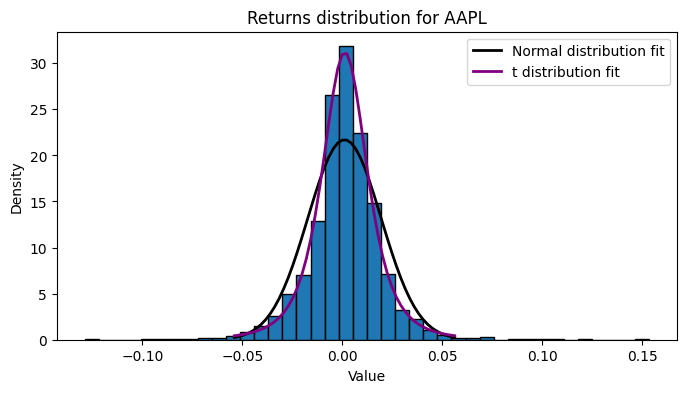

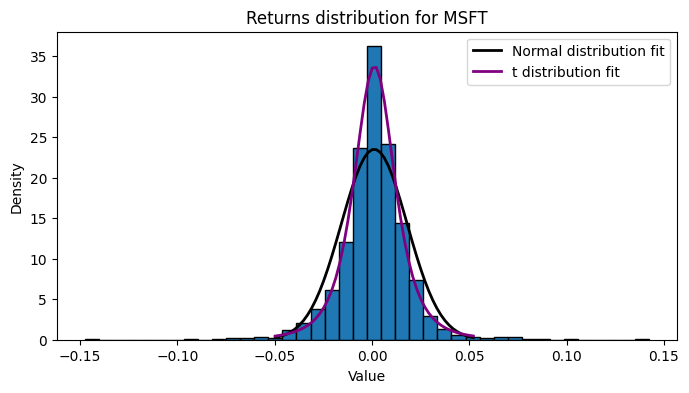

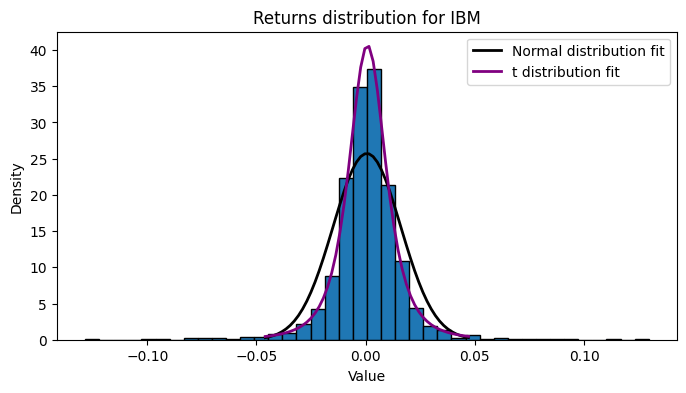

In [23]:
mask = ['AAPL', 'MSFT', 'IBM']
generate_histograms(returns_close_10y_1d[mask], statistics, figsize=(8,4), dpi=100)

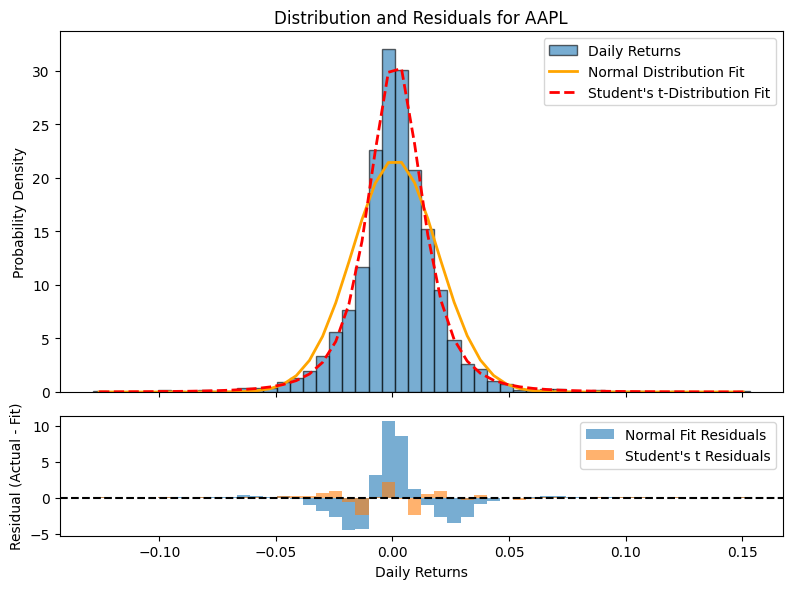

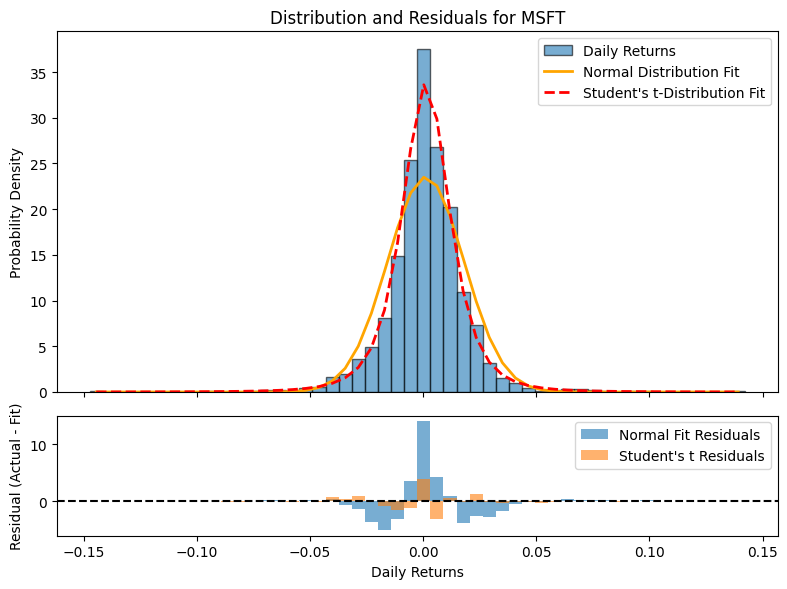

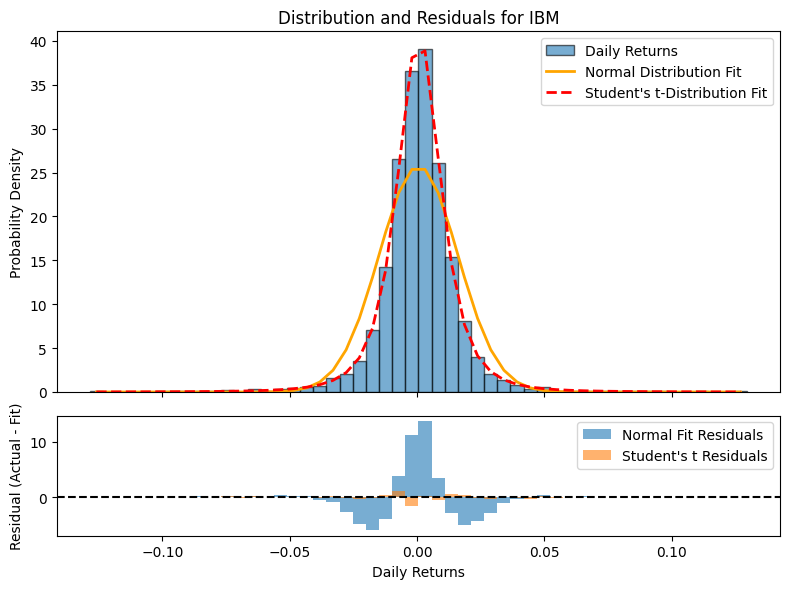

In [24]:
generate_histograms_with_residuals(returns_close_10y_1d[mask], figsize=(8, 6))

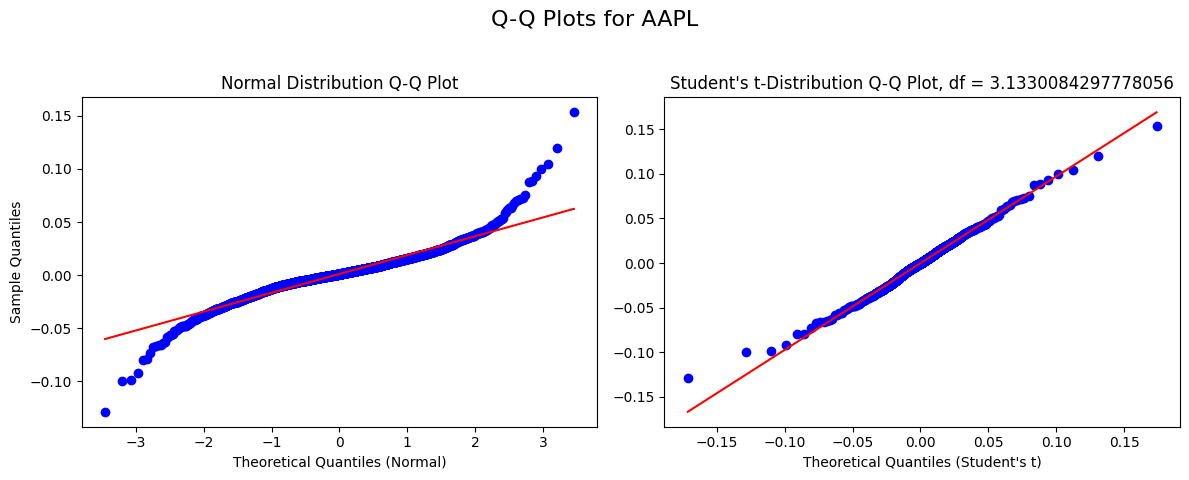

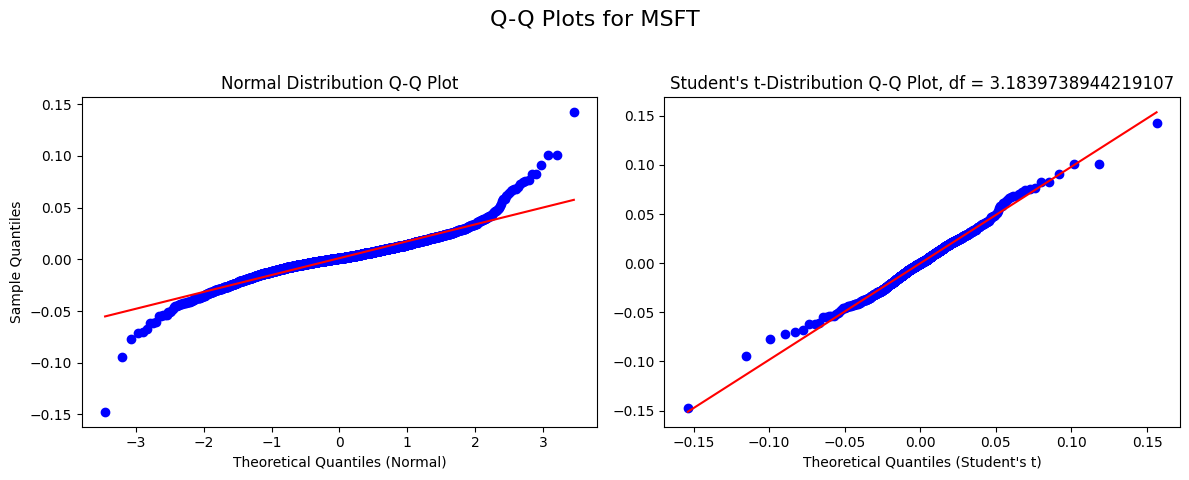

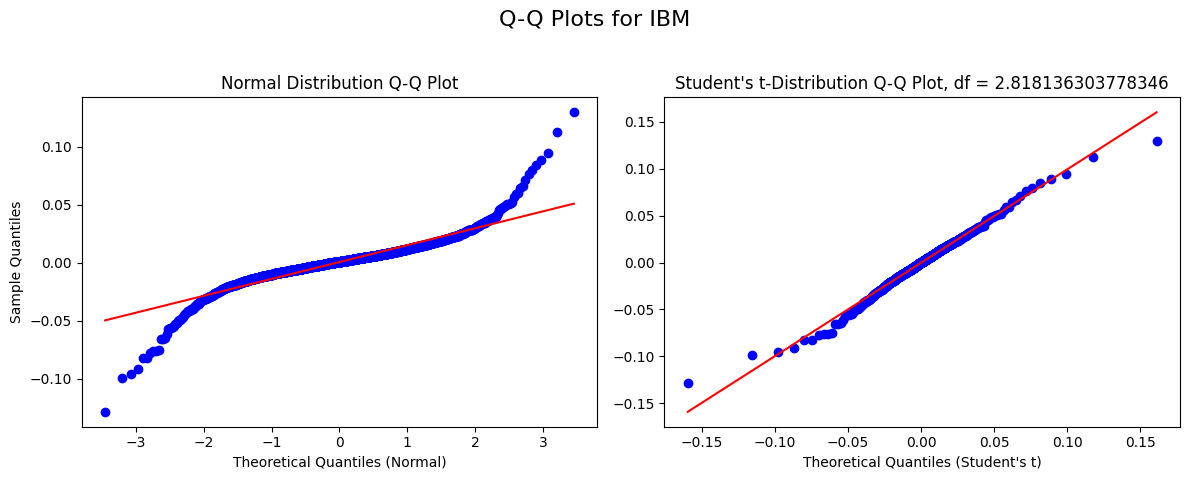

In [31]:
generate_qq_plots(returns_close_10y_1d[mask])

Let's analyze now some important events that have happened during the last 5-10 years to see what would be the influence of these events on the stocks we are holding

In [82]:
# Define event windows

event_windows = {
    "COVID_crash": ("2020-02-20", "2020-04-07"),
    "Elections_OctNov2024": ("2024-10-01", "2024-11-30"),
    "Tariffs_April2025": ("2025-04-01", "2025-04-30"),
    "Pre_2018": ("2016-01-01", "2017-12-31"),
    "Post_2022": ("2022-01-01", "2023-12-31"),
}

# Validate: convert to datetimes
event_windows_dt = {k: (pd.to_datetime(v[0]), pd.to_datetime(v[1])) for k,v in event_windows.items()}

We can visualize how the prices of the stocks behaved during these specific events

C:\Users\Jujop\AppData\Local\Temp\ipykernel_13216\2127775905.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 5))


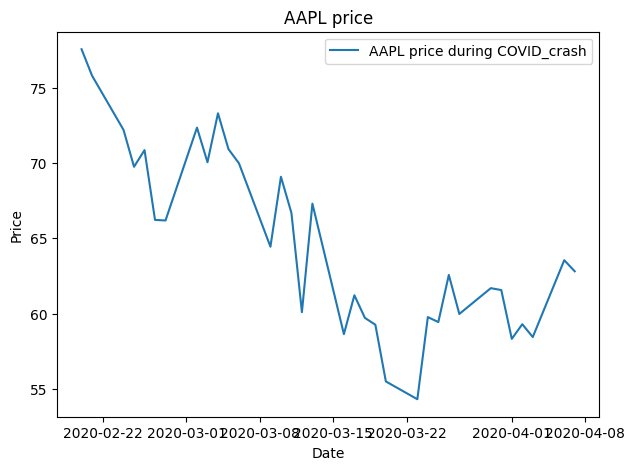

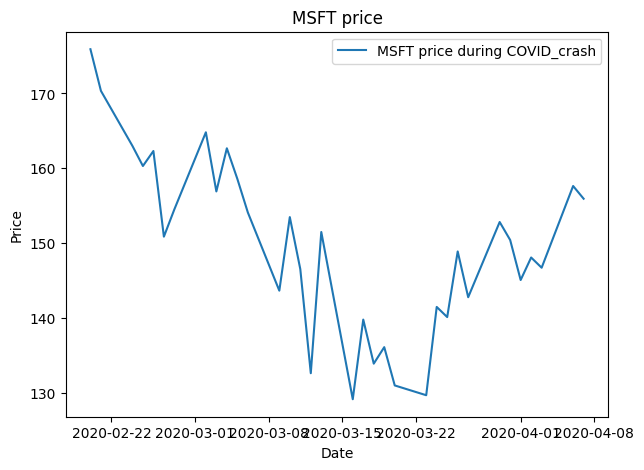

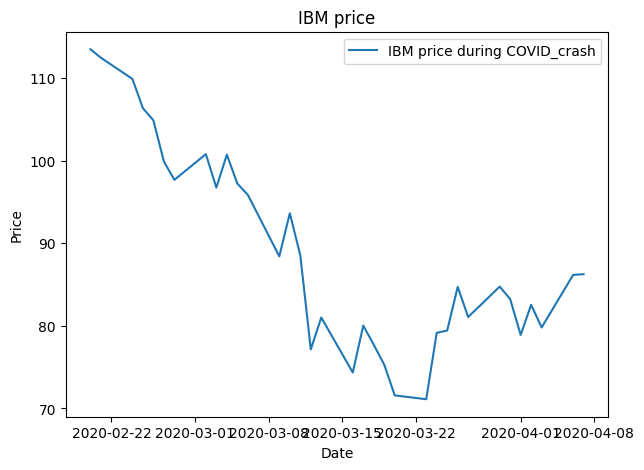

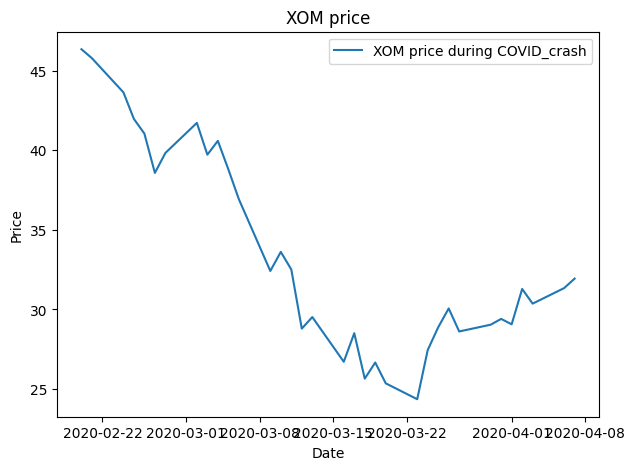

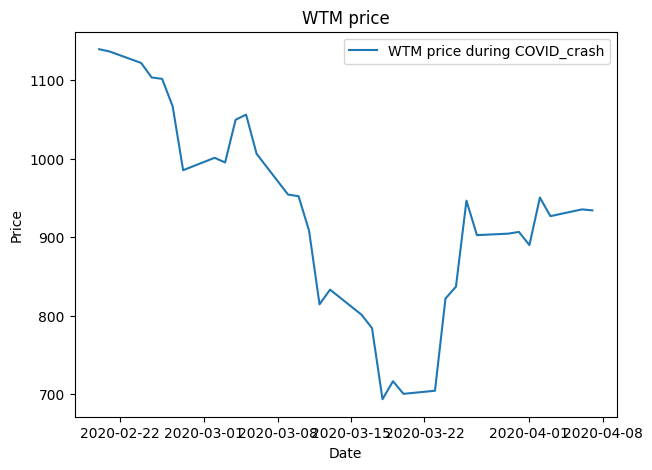

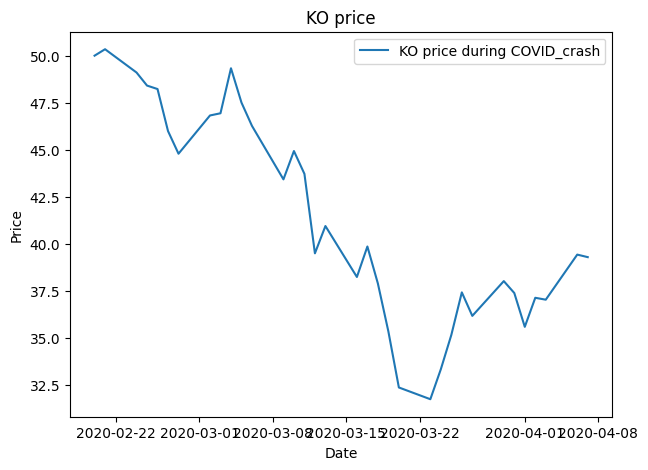

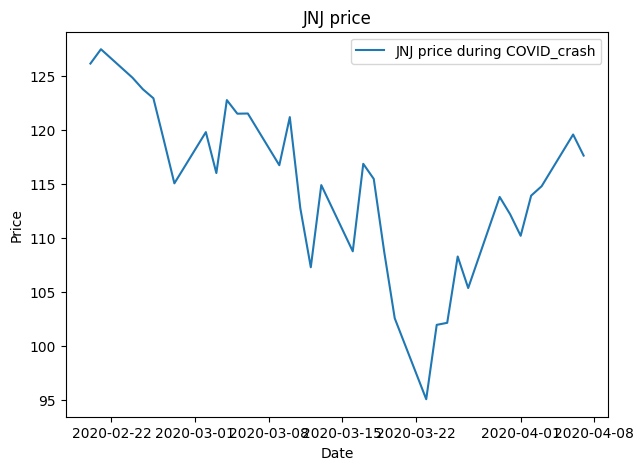

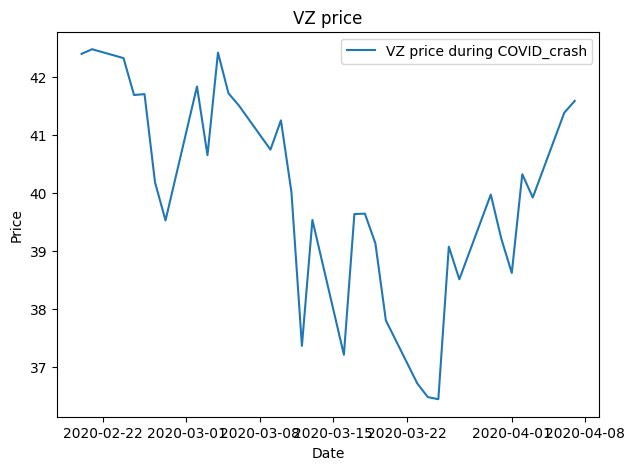

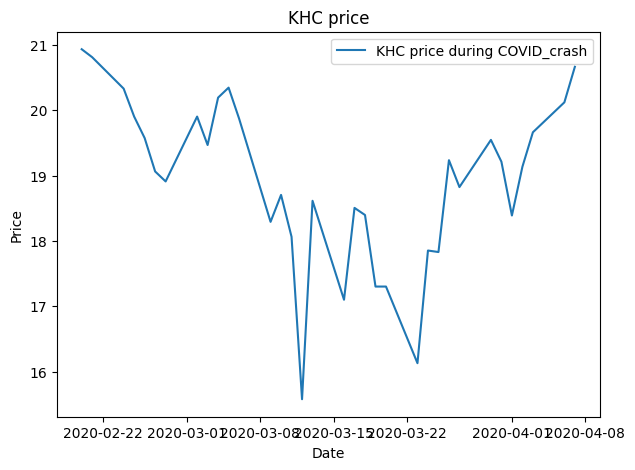

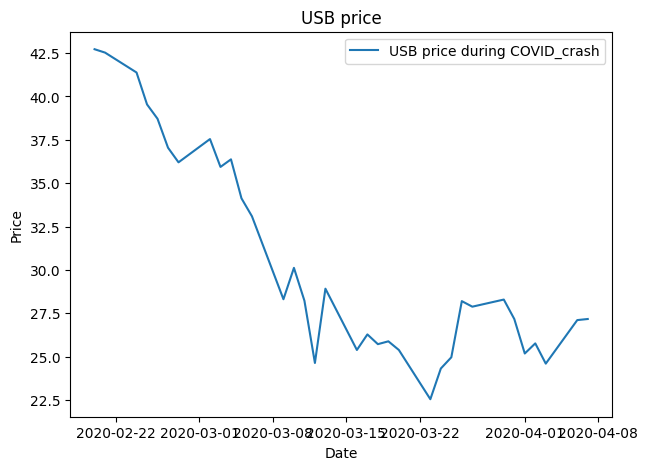

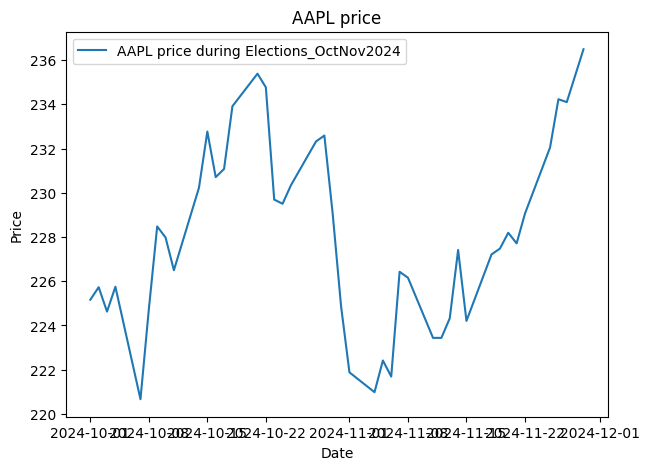

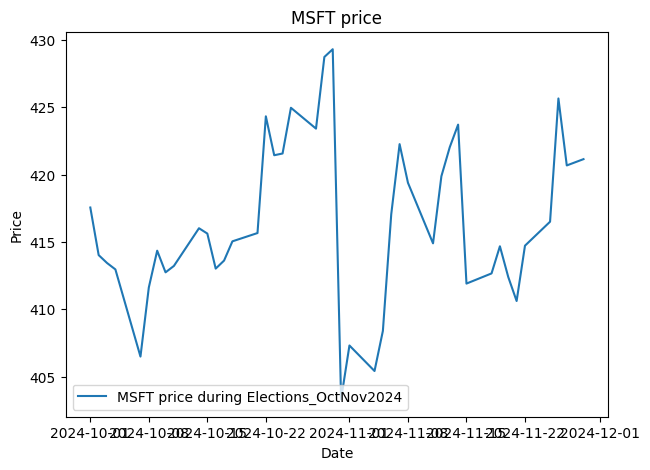

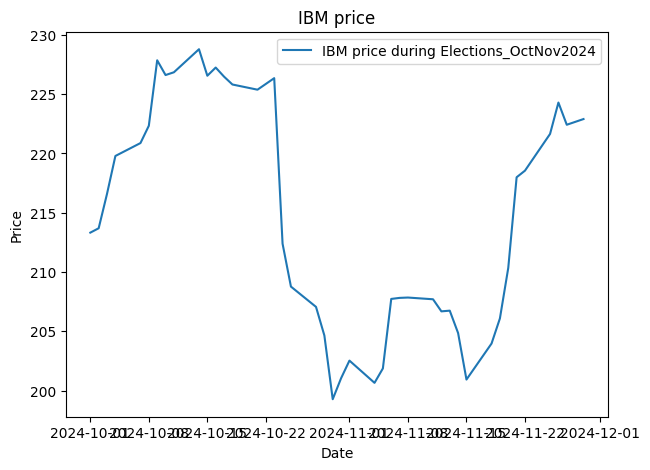

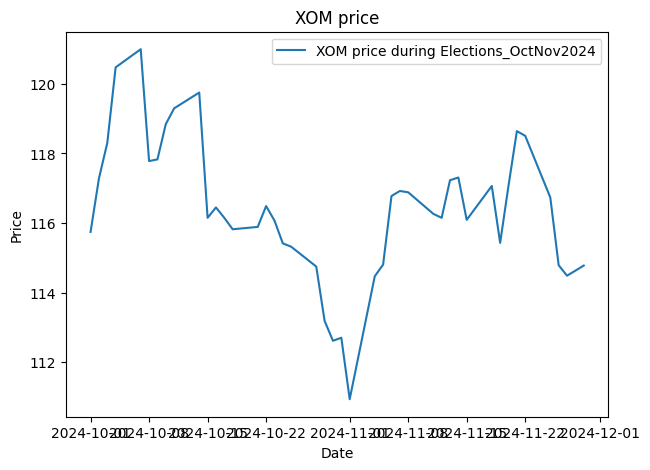

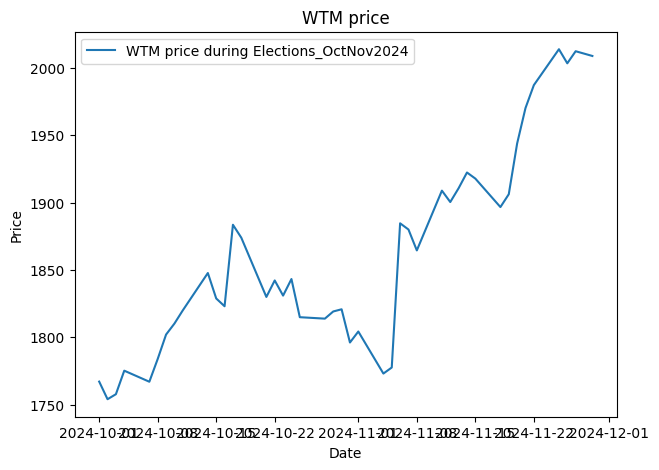

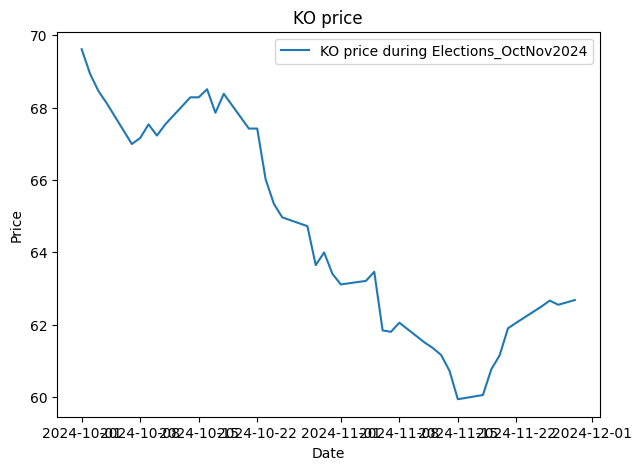

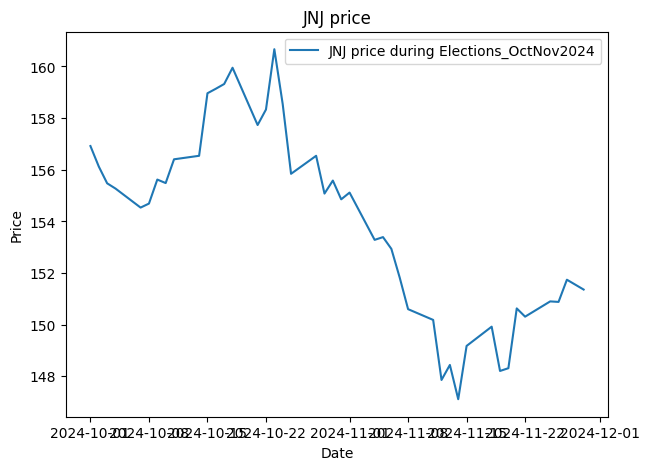

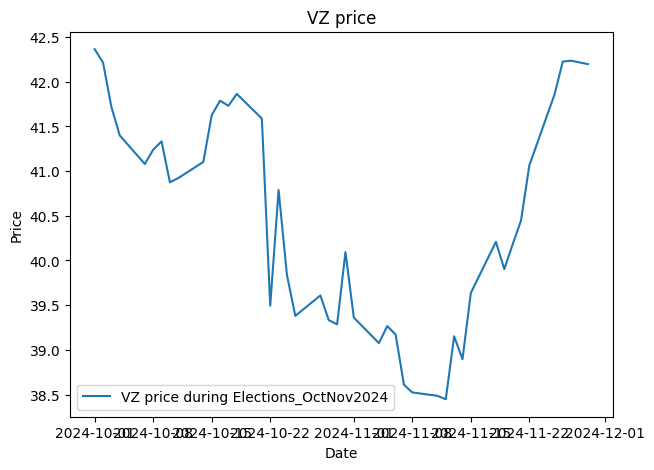

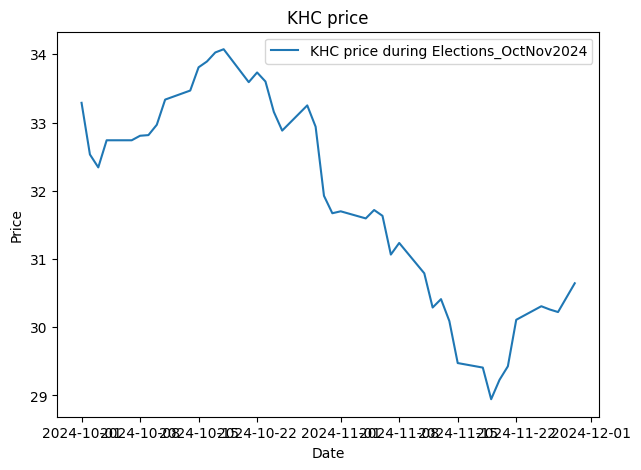

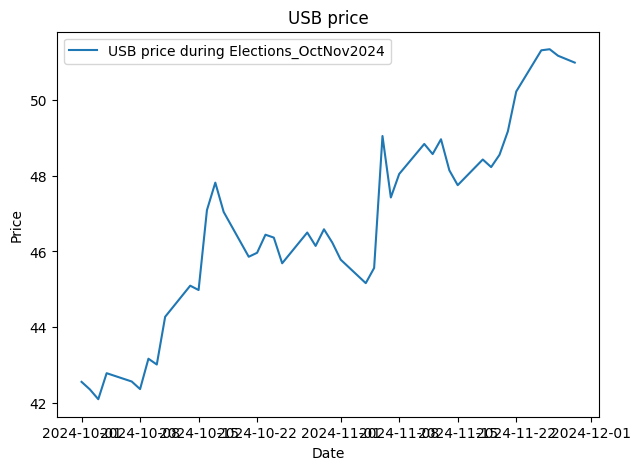

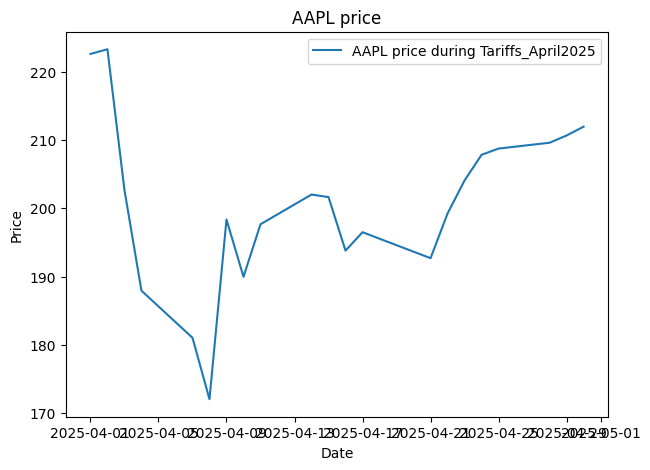

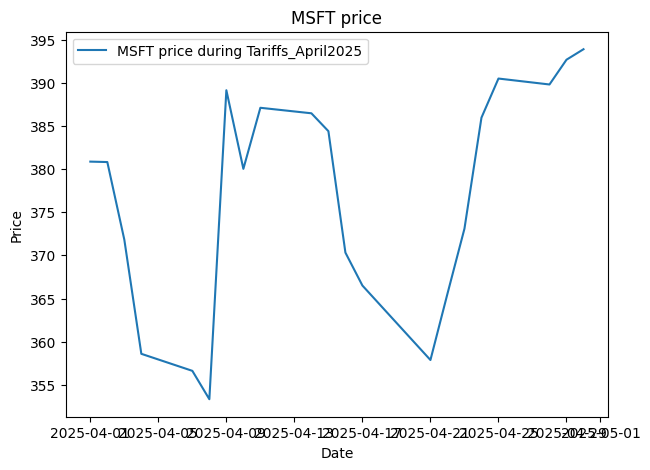

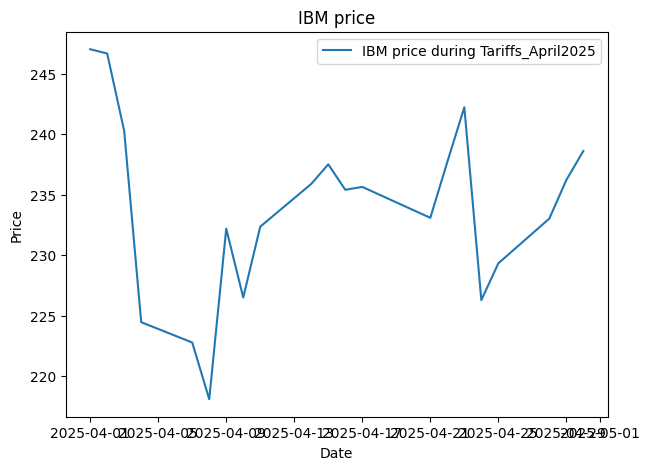

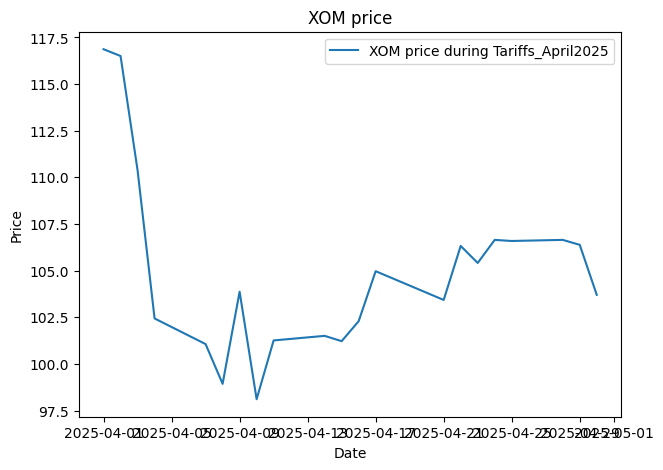

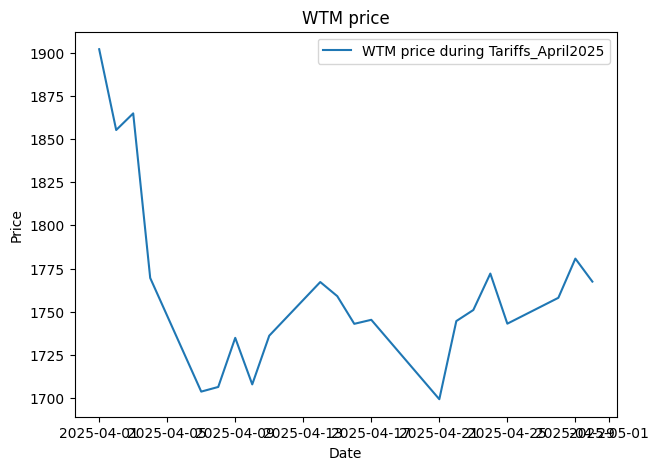

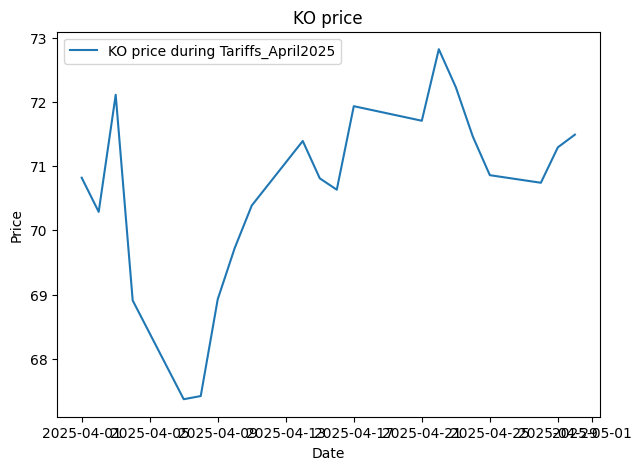

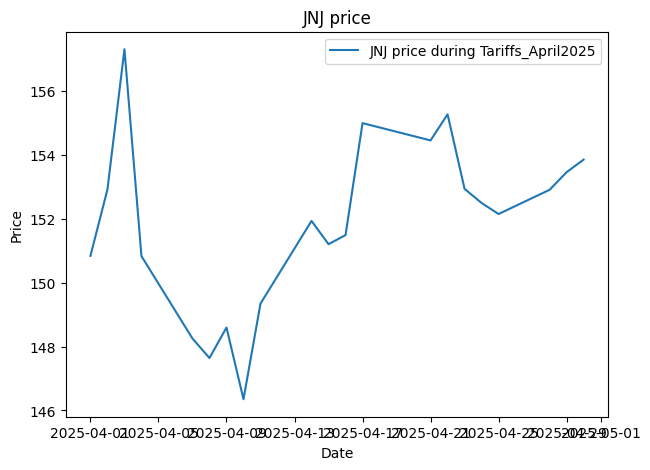

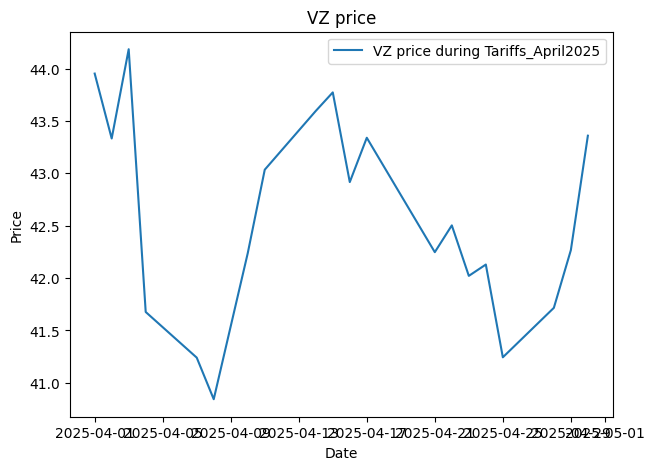

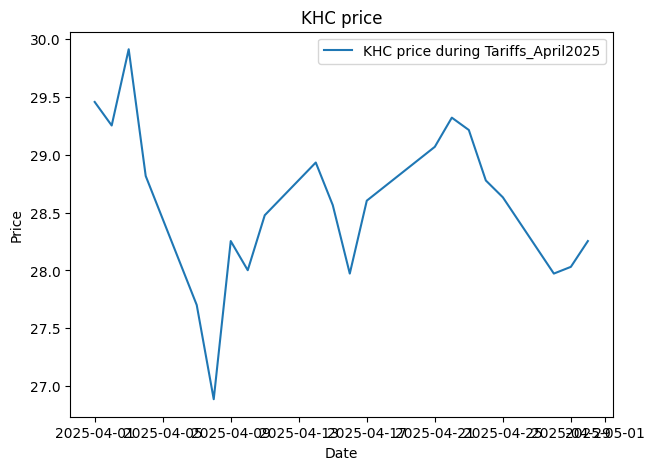

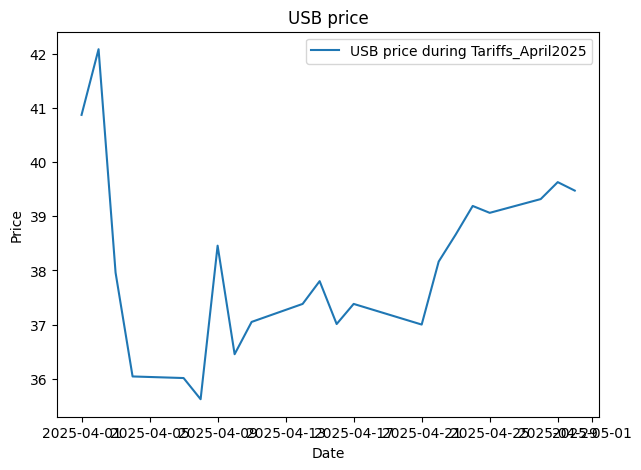

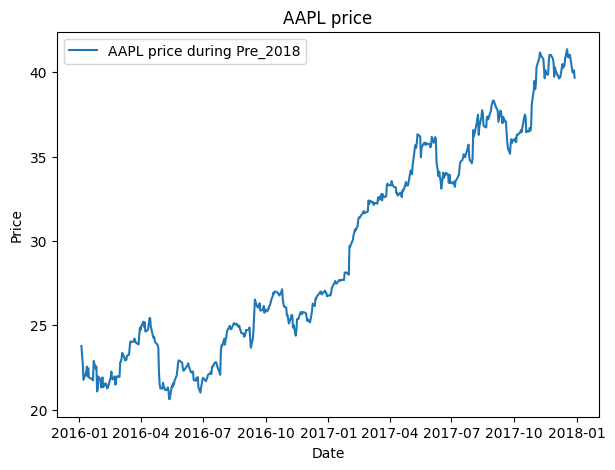

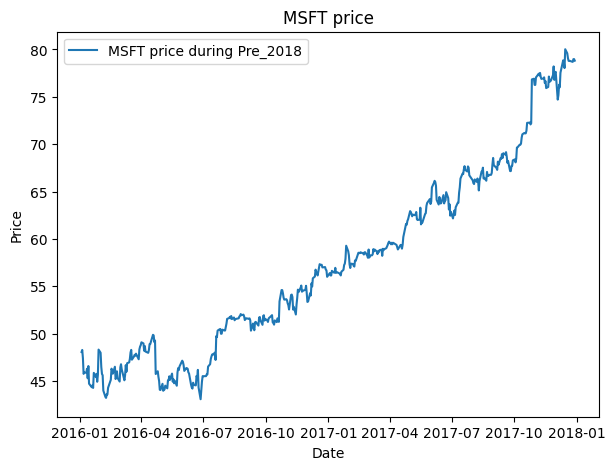

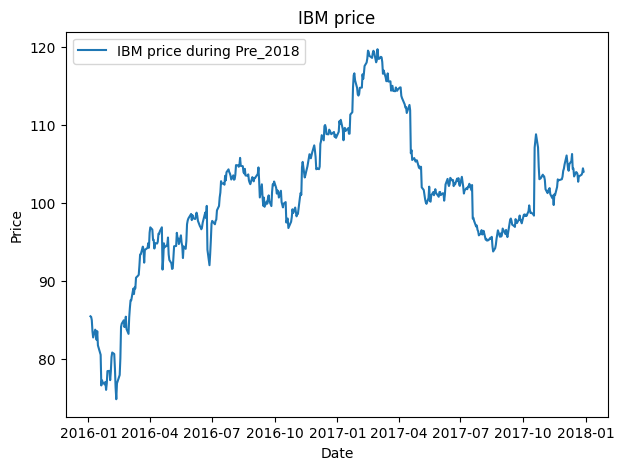

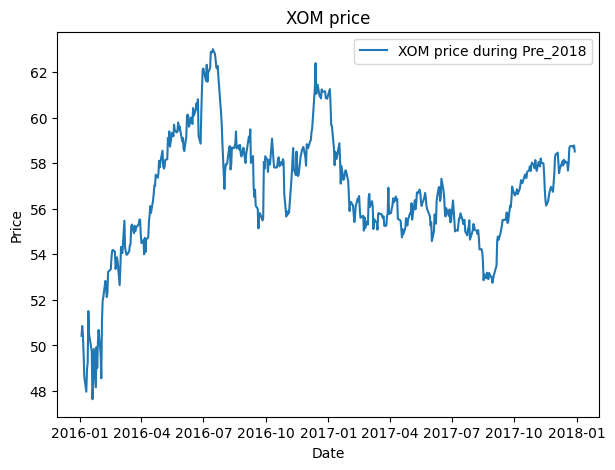

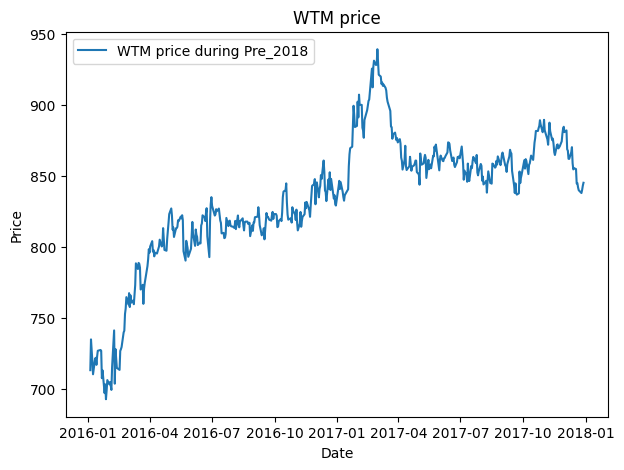

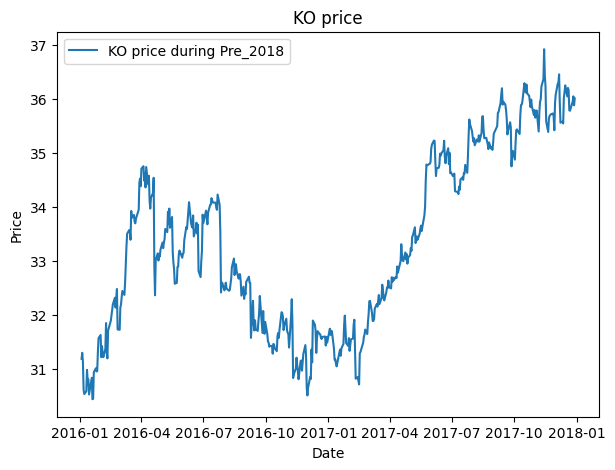

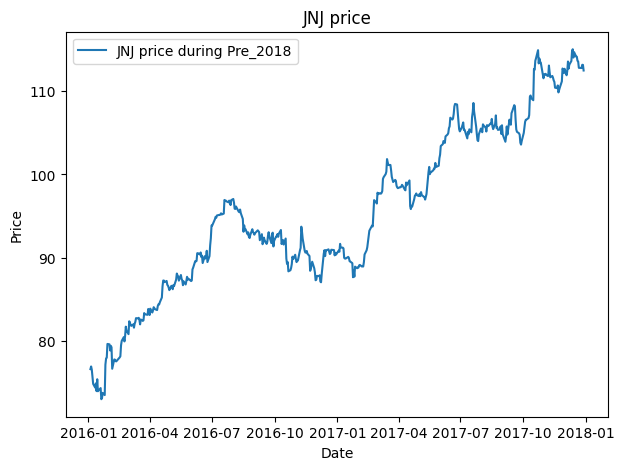

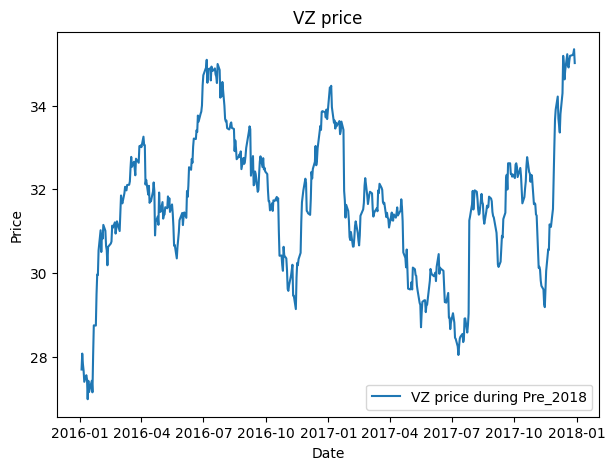

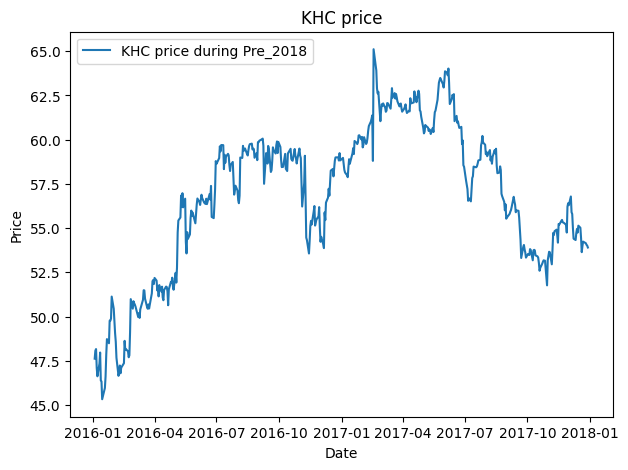

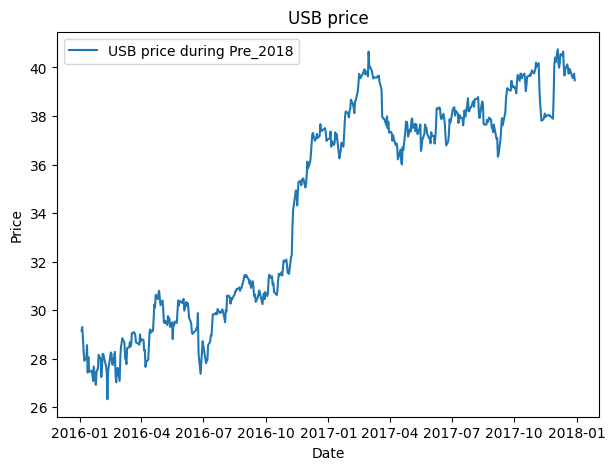

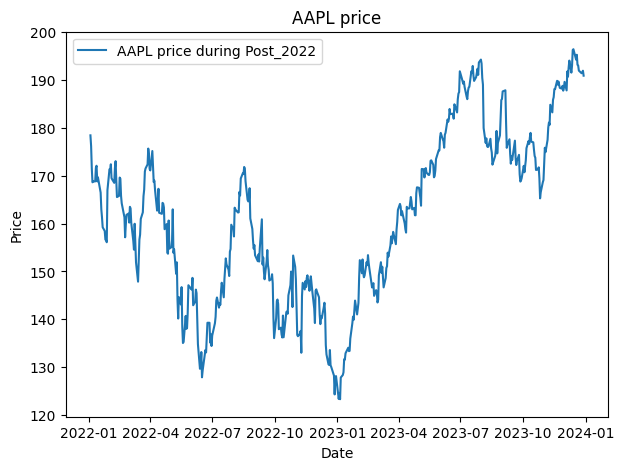

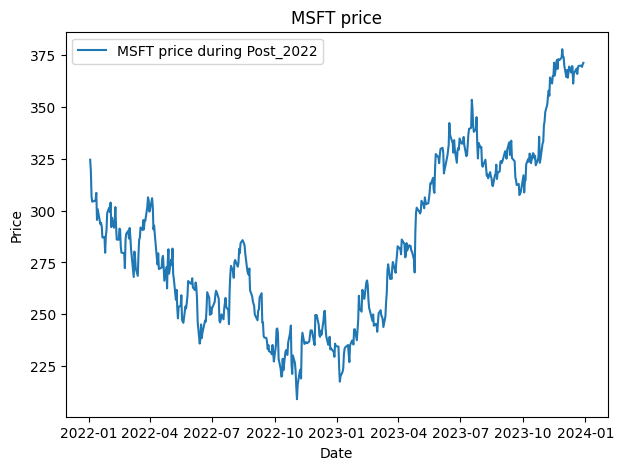

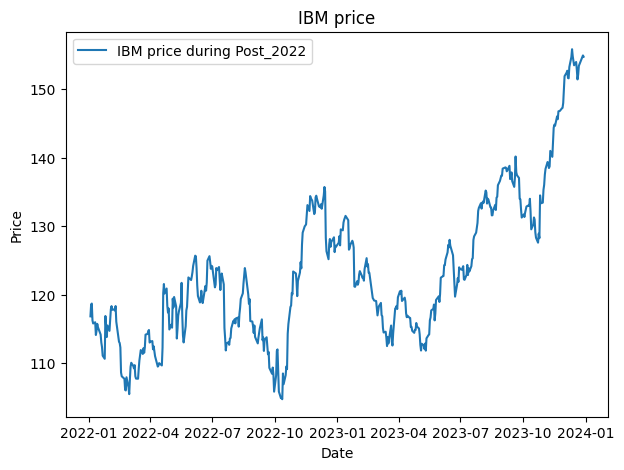

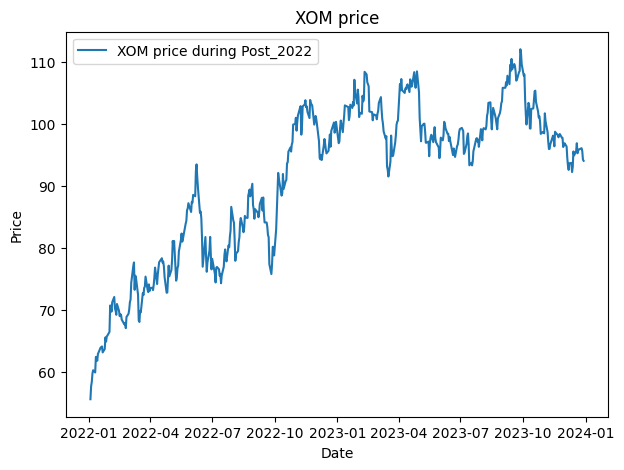

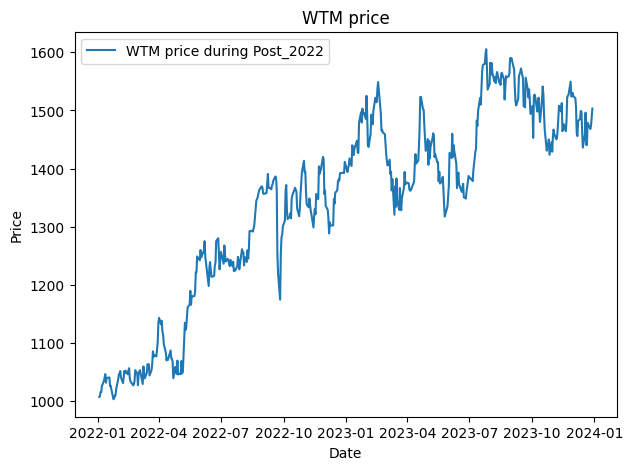

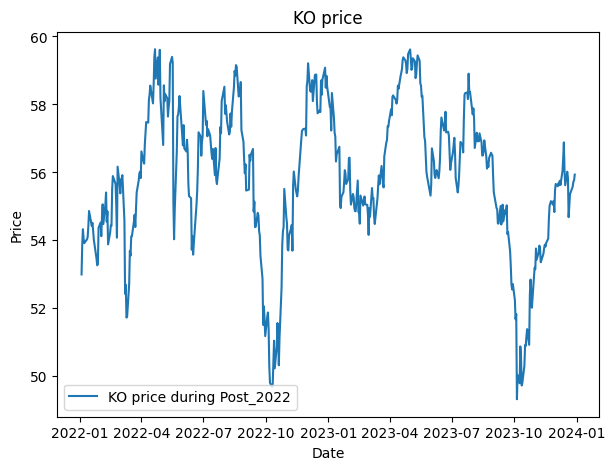

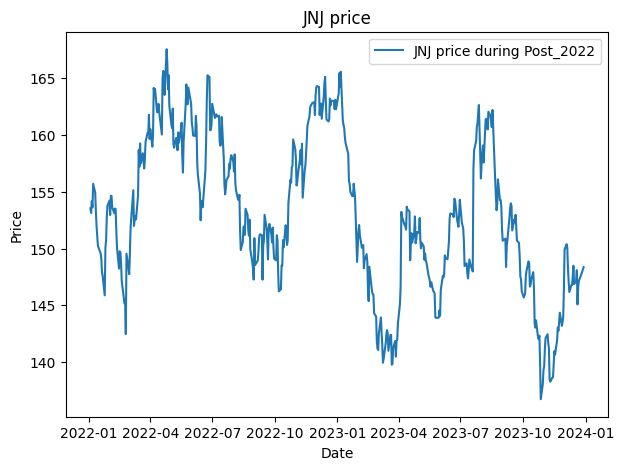

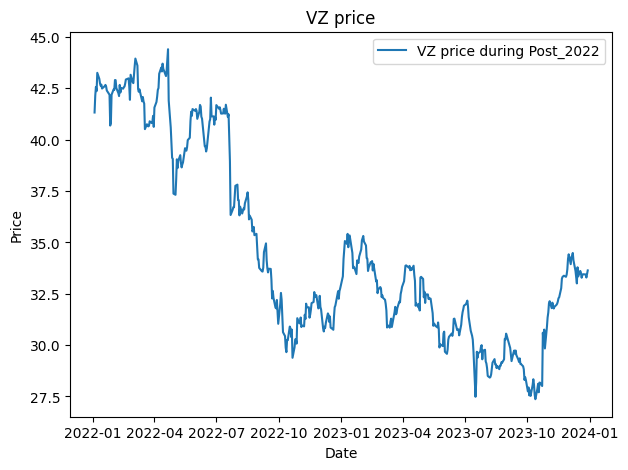

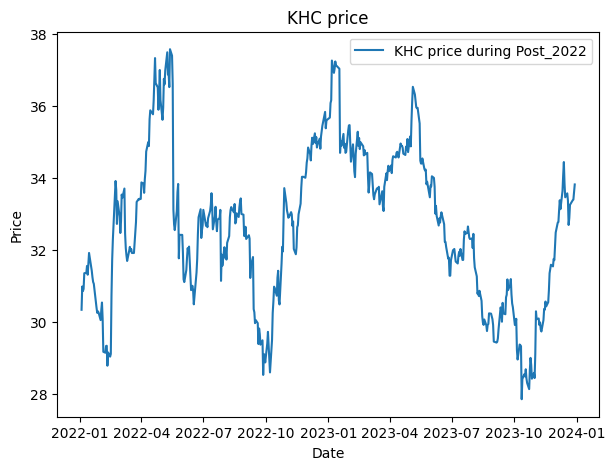

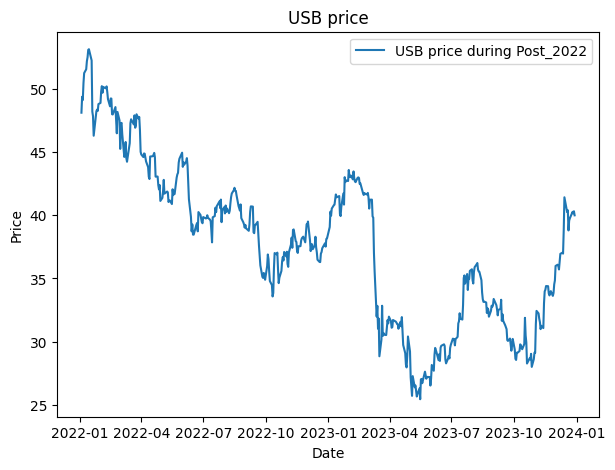

In [83]:
for event in event_windows.keys():
    for ticker in data_close_10y_1d.columns:
        plt.figure(figsize=(7, 5))
        plt.plot(data_close_10y_1d[ticker].loc[event_windows_dt[f'{event}'][0]:event_windows_dt[f'{event}'][1]], label=f'{ticker} price during {event}')
        plt.ylabel('Price')
        plt.xlabel('Date')
        plt.title(f'{ticker} price')
        plt.legend()
        

In [84]:
# For each ticker and event window compute stats

event_stats = {}
for event, timeframe in event_windows_dt.items():
    start = timeframe[0]
    end = timeframe[1]
    stats = descriptive_statistics(returns_close_10y_1d.loc[start:end])
    event_stats[f'{event}'] = pd.DataFrame(stats)

Now we can compare some statistics of these returns, in theory we should expect diminished or negative returns for this high uncertainty periods and a high increase in volatility

In [85]:
# Filter the statistics we want to compare
rows = ['mean', 'std', 'skewness']

statistics.loc[rows]

,AAPL,MSFT,IBM,XOM,WTM,KO,JNJ,VZ,KHC,USB
mean,0.001099,0.001156,0.000572,0.000485,0.000468,0.000383,0.000452,0.000280,-0.000084,0.000382
std,0.018383,0.016962,0.015514,0.017649,0.014645,0.011362,0.011573,0.012421,0.016961,0.019067
skewness,0.150630,0.152732,-0.210243,0.022536,0.711782,-0.677916,-0.229382,0.061230,-1.231078,0.062558


In [86]:
event_stats['COVID_crash'].loc[rows]

,AAPL,MSFT,IBM,XOM,WTM,KO,JNJ,VZ,KHC,USB
mean,-0.004905,-0.002260,-0.006626,-0.009539,-0.004523,-0.006081,-0.001228,-0.000079,0.001448,-0.010871
std,0.057091,0.059684,0.052506,0.056933,0.054546,0.045515,0.044125,0.033959,0.060061,0.069240
skewness,0.326273,0.204620,0.247313,0.030804,1.007908,-0.048841,0.362961,0.524547,0.768302,0.476359


In [89]:
event_stats['COVID_crash'].loc['std'] / statistics.loc['std']

AAPL    3.105627
MSFT    3.518654
IBM     3.384326
XOM     3.225933
WTM     3.724480
KO      4.005956
JNJ     3.812779
VZ      2.734025
KHC     3.541174
USB     3.631344
Name: std, dtype: float64

As expected, we can see that during the COVID crash in 2020, the returns were much lower, inclusive negative, than the average returns for the whole time-series. Note as well that the volatility during these period increased by a factor between 3 and 4 for the majority of the stocks.  

## Analysis in presence of dividends (KO)

**On the ex-divident (without dividend) date:**

Theoretically, a stock price should drop by the exact amount of the dividend on the ex-dividend date, as the company's cash is being paid out and its value is reduced. However, in reality the drop is often slightly less than the dividend amount due to factors like taxes and other market fluctuations. For large dividends, the price drop is usually more noticeable, but for small dividends, it can be masked by normal daily price swings. 

This can be influenced by:

* **Taxes:** The impact of taxes on dividend income can cause the price to drop slightly less than the dividend itself.
* **Market fluctuations:** Other buying and selling activity can influence the stock price, meaning the dividend's impact can be masked by regular market movements.
* **Efficiency:** Stock price movements are generally efficient, and the market has already priced in the expected dividend payment.

Noticeability: The impact of a dividend is more easily observed with larger dividend payments. For smaller dividends, the drop can be too small to be easily detected amid the stock's normal daily price changes. 

For KO we have the following information on their dividends and the dates they are offered, the information was collected from here: https://investors.coca-colacompany.com/stock-info/dividends

In [2]:
KO_dividends_2008 = pd.read_csv("../data/raw/KO_dividends_2008.csv")

In [3]:
KO_dividends_2008.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ex-Div Date  71 non-null     object
 1   Amount       71 non-null     object
 2   Frequency    71 non-null     object
 3   Payment      71 non-null     object
 4   Record       71 non-null     object
 5   Announced    71 non-null     object
 6   Type         71 non-null     object
dtypes: object(7)
memory usage: 4.0+ KB


In [4]:
# Cast dates column to datetime object and clean amount column
dt_columns = ['Ex-Div Date', 'Payment', 'Record', 'Announced']
KO_dividends_2008[dt_columns] = KO_dividends_2008[dt_columns].apply(pd.to_datetime, format="%m/%d/%Y")
KO_dividends_2008['Amount'] = KO_dividends_2008['Amount'].apply(lambda x: x.split()[0]).astype(float)

Key concepts:

* The ex-dividend date is the cut-off for new buyers to qualify for the next dividend.
* The record date is the day a company finalizes which shareholders will receive the dividend.
* From 2024, the ex-dividend and record dates are the same due to T+1 settlement.
* Stock prices often drop by the dividend amount on the ex-dividend date.
* Shareholders can sell on the record date and still receive dividends if bought before the ex-date.

A person purchasing a stock before its ex-dividend date, and holding the position before the market opens on the ex-dividend date, is by convention entitled to the dividend. A person purchasing a stock on its ex-dividend date or after will not receive the current dividend payment.

In [5]:
KO_dividends_2008

,Ex-Div Date,Amount,Frequency,Payment,Record,Announced,Type
0,2025-09-15,0.510,Quarterly,2025-10-01,2025-09-15,2025-07-17,Cash Dividend
1,2025-06-13,0.510,Quarterly,2025-07-01,2025-06-13,2025-05-01,Cash Dividend
2,2025-03-14,0.510,Quarterly,2025-04-01,2025-03-14,2025-02-20,Cash Dividend
3,2024-11-29,0.485,Quarterly,2024-12-16,2024-11-29,2024-10-17,Cash Dividend
4,2024-09-13,0.485,Quarterly,2024-10-01,2024-09-13,2024-07-29,Cash Dividend
...,...,...,...,...,...,...,...
66,2009-03-11,0.410,Quarterly,2009-04-01,2009-03-15,2009-02-19,Cash Dividend
67,2008-11-26,0.380,Quarterly,2008-12-15,2008-12-01,2008-10-16,Cash Dividend
68,2008-09-11,0.380,Quarterly,2008-10-01,2008-09-15,2008-07-17,Cash Dividend
69,2008-06-11,0.380,Quarterly,2008-07-01,2008-06-15,2008-04-17,Cash Dividend


Bid ask signal
momentum maybe (?)

Auto correlation function
Partial ACF


For HF consider quarterly to monthly place trades

How close does it looks like a t dist? Try to compare with other distributions

How significant it is? with respect to the t

1. Capture cash dividends, see what effect that has on the daily, and then move into intraday, see how a day trader may.


Do a KS test

max(abs(CDF empirical - CDF theorical))

### Clean Treasury bills data

In [17]:
riskfree_rate = pd.read_csv('../data/raw/DTB3.csv',
                            index_col='observation_date',
                            parse_dates=True)
riskfree_rate.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2835 entries, 2015-01-02 to 2025-11-13
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DTB3    2718 non-null   float64
dtypes: float64(1)
memory usage: 44.3 KB


In [18]:
riskfree_rate.ffill(inplace=True)
riskfree_rate.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2835 entries, 2015-01-02 to 2025-11-13
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DTB3    2835 non-null   float64
dtypes: float64(1)
memory usage: 44.3 KB


In [22]:
riskfree_rate /= 100

In [25]:
riskfree_rate.to_csv('../data/processed/risk_free.csv')

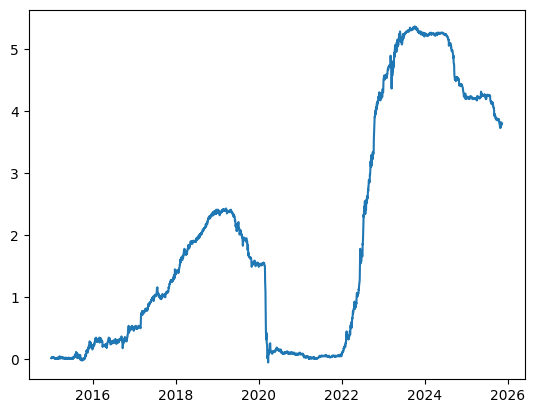

In [20]:
plt.plot(riskfree_rate)